In [1]:
from src.history import load_history

In [8]:
history_no_aug= load_history("history/baseline_resnet.pkl")

In [9]:
history_aug= load_history("history/data_aug_resnet.pkl")

In [10]:
history_dropout= load_history("history/dropout_resnet.pkl")

In [11]:
history_width160= load_history("history/witdth_resnet.pkl")

In [7]:
import matplotlib.pyplot as plt

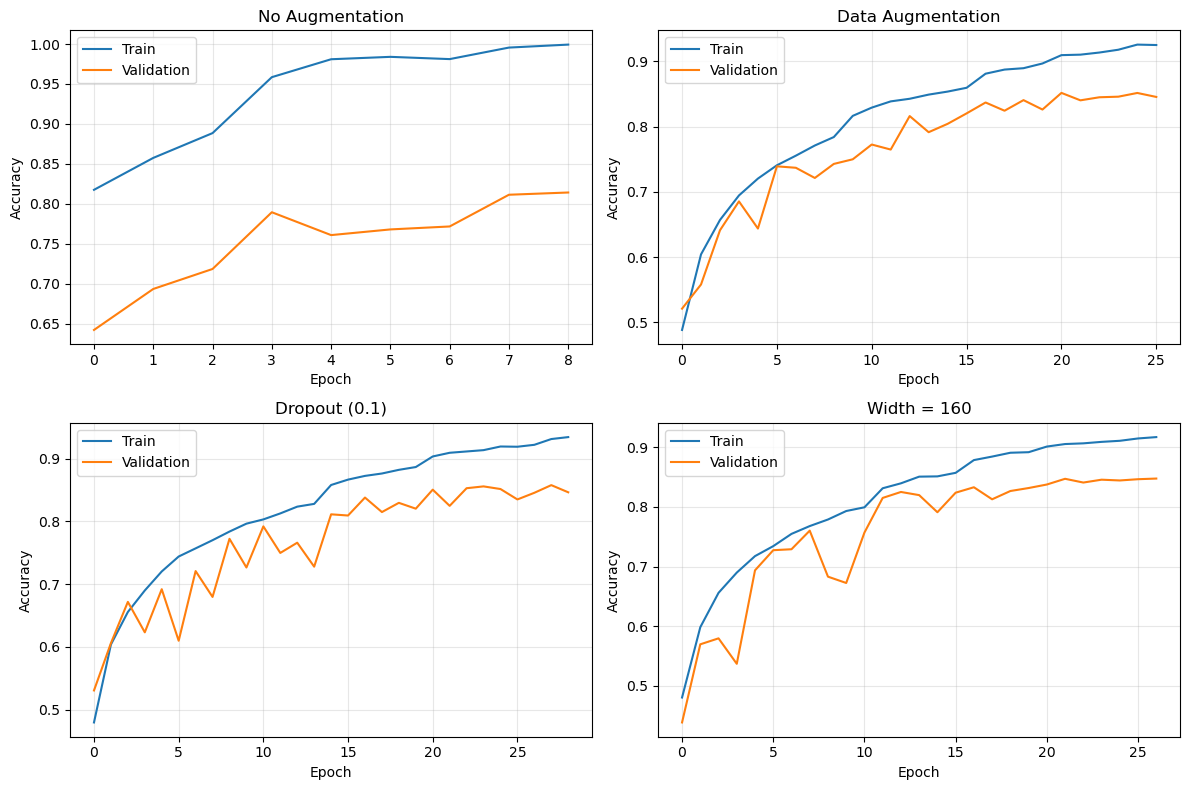

In [22]:
histories = [
    ("No Augmentation", history_no_aug),
    ("Data Augmentation", history_aug),
    ("Dropout (0.1)", history_dropout),
    ("Width = 160", history_width160)
]

fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, (title, history) in zip(axes.flat, histories):
    ax.plot(history["accuracy"], label="Train")
    ax.plot(history["val_accuracy"], label="Validation")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(
    "images/training_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

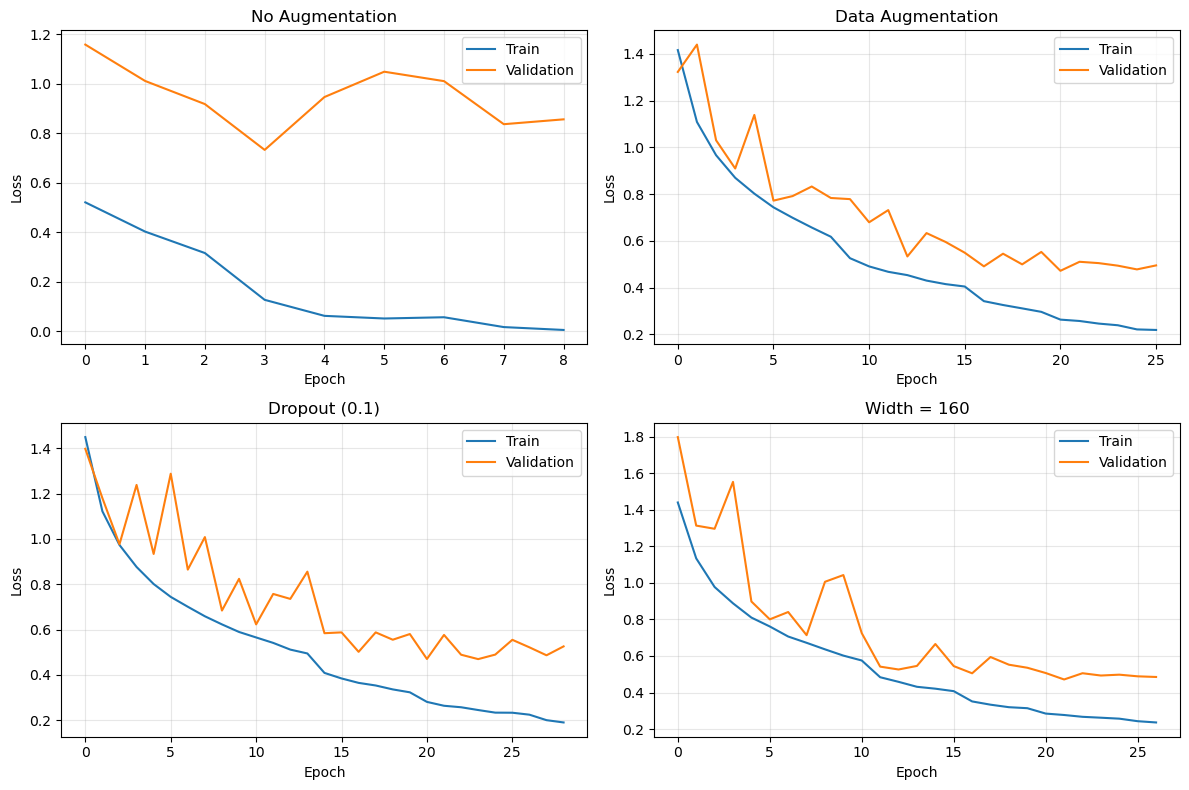

In [23]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, (title, history) in zip(axes.flat, histories):
    ax.plot(history["loss"], label="Train")
    ax.plot(history["val_loss"], label="Validation")

    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig(
    "images/training_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [19]:
import tensorflow as tf
no_aug_model= tf.keras.models.load_model('E:/AI_projects/resnet-cifar10/models/baseline_resnet.keras')
aug_model= tf.keras.models.load_model('E:/AI_projects/resnet-cifar10/models/with_data_aug_resnet.keras')
dropout_model= tf.keras.models.load_model('E:/AI_projects/resnet-cifar10/models/dropout_resnet.keras')
width160_model= tf.keras.models.load_model('E:/AI_projects/resnet-cifar10/models/width_resnet.keras')

In [20]:
from src.dataset import load_cifar10
(X_train, Y_train), (X_test, Y_test) = load_cifar10()

models = [no_aug_model, aug_model, dropout_model, width160_model]

test_acc=[]
for model in models:
    _, acc = model.evaluate(X_test, Y_test, verbose=2)
    test_acc.append(acc)

313/313 - 6s - 20ms/step - accuracy: 0.7856 - loss: 0.7683
313/313 - 6s - 18ms/step - accuracy: 0.8397 - loss: 0.5026
313/313 - 7s - 22ms/step - accuracy: 0.8501 - loss: 0.4801
313/313 - 6s - 20ms/step - accuracy: 0.8447 - loss: 0.4910


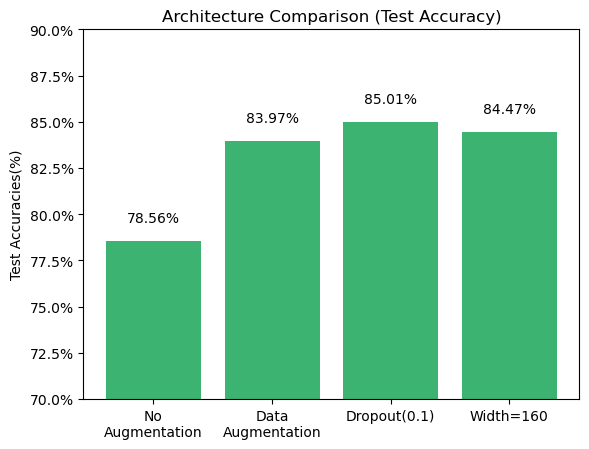

In [24]:
from matplotlib.ticker import PercentFormatter
# Sample data
archs = ['No\nAugmentation', 'Data\nAugmentation', 'Dropout(0.1)', 'Width=160']

acc_pct= [a*100 for a in test_acc]

plt.bar(archs, acc_pct, color= 'mediumseagreen')

plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=100))

plt.ylabel('Test Accuracies(%)')
plt.title('Architecture Comparison (Test Accuracy)')
plt.ylim(70, 90)
for i, p in enumerate(acc_pct):
    plt.text(i, p+1, f'{p:.2f}%', ha='center')

plt.savefig(
    "images/test_acc_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

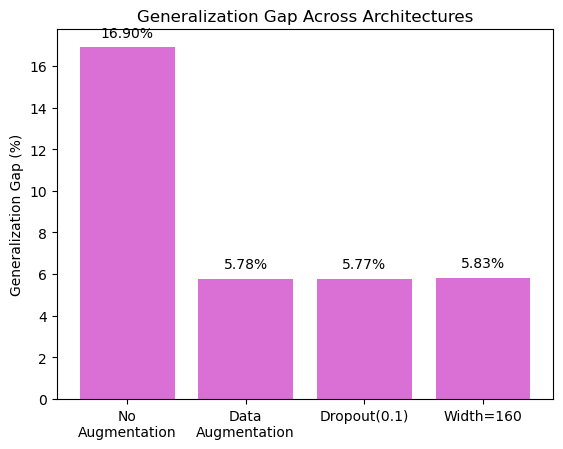

In [62]:
gaps = []
for _, h in histories:
    best_epoch_idx = np.argmin(h["val_loss"])
    
    train_acc = h["accuracy"][best_epoch_idx]
    val_acc   = h["val_accuracy"][best_epoch_idx]
    
    gaps.append((train_acc - val_acc) * 100)


plt.bar(archs, gaps, color='orchid')
plt.ylabel('Generalization Gap (%)')
plt.title('Generalization Gap Across Architectures')

for i, g in enumerate(gaps):
    plt.text(i, g + 0.5, f'{g:.2f}%', ha='center')

plt.savefig(
    "images/gen_gap_bar_chart.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


In [47]:
lists=[]
for _, h in histories:
    best_loss = min(h["val_loss"])       
    #best_val   = max(h["val_accuracy"])   
    lists.append(best_loss)

In [61]:
d= lists[3]
print(f'{d:.4f}')

0.4714


In [60]:
import numpy as np

best_epoch_idx = np.argmin(history_width160["val_loss"])

best_train_acc = history_width160["accuracy"][best_epoch_idx]
best_val_acc   = history_width160["val_accuracy"][best_epoch_idx]

print("Best val_loss at epoch:", best_epoch_idx + 1)
print(f"Train acc at best val_loss: {best_train_acc*100:.2f}")
print(f"Val acc at best val_loss: {best_val_acc*100:.2f}")

Best val_loss at epoch: 22
Train acc at best val_loss: 90.55
Val acc at best val_loss: 84.72
